In [ ]:
!pip install yfinance


In [ ]:
import yfinance as yf
import pandas as pd


In [ ]:
class AlgorithmicTrader:
    def __init__(self, symbol, start_date, end_date, capital=5000):
        self.symbol = symbol
        self.start_date = start_date
        self.end_date = end_date
        self.capital = capital

        self.data = None
        self.position = 0
        self.cash = capital
        self.buy_price = 0
        self.trades = []

    def fetch_data(self):
        self.data = yf.download(
            self.symbol,
            start=self.start_date,
            end=self.end_date
        )

    def clean_data(self):
        self.data = self.data[~self.data.index.duplicated()]
        self.data.fillna(method="ffill", inplace=True)

    def compute_indicators(self):
        self.data["MA50"] = self.data["Close"].rolling(50).mean()
        self.data["MA200"] = self.data["Close"].rolling(200).mean()

    def execute_strategy(self):
      for i in range(1, len(self.data)):
          prev = self.data.iloc[i - 1]
          curr = self.data.iloc[i]

          prev_ma50 = float(prev["MA50"])
          prev_ma200 = float(prev["MA200"])
          curr_ma50 = float(curr["MA50"])
          curr_ma200 = float(curr["MA200"])
          curr_price = float(curr["Close"])

          # BUY - Golden Cross
          if (
              prev_ma50 < prev_ma200
              and curr_ma50 > curr_ma200
              and self.position == 0
          ):
              quantity = int(self.cash // curr_price)

              if quantity > 0:
                  self.position = quantity
                  self.cash -= quantity * curr_price
                  self.trades.append(
                      (curr.name, "BUY", curr_price, quantity)
                  )

          # SELL - Death Cross
          elif (
              prev_ma50 > prev_ma200
              and curr_ma50 < curr_ma200
              and self.position > 0
          ):
              self.cash += self.position * curr_price
              self.trades.append(
                  (curr.name, "SELL", curr_price, self.position)
              )
              self.position = 0

      # Force close on last day
      if self.position > 0:
          last_price = float(self.data.iloc[-1]["Close"])
          self.cash += self.position * last_price
          self.trades.append(
              (self.data.index[-1], "FORCE SELL", last_price, self.position)
          )
          self.position = 0

    def evaluate(self):
        return self.cash - self.capital

    def run(self):
        self.fetch_data()
        self.clean_data()
        self.compute_indicators()
        self.execute_strategy()
        profit = self.evaluate()

        print(f"Final Cash: ${self.cash:.2f}")
        print(f"Profit/Loss: ${profit:.2f}")
        print("\nTrades:")
        for t in self.trades:
            print(t)


In [ ]:
trader = AlgorithmicTrader(
    "AAPL",
    "2018-01-01",
    "2023-12-31"
)

trader.run()


/tmp/ipython-input-1993168180.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1993168180.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.data.fillna(method="ffill", inplace=True)
/tmp/ipython-input-1993168180.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_ma50 = float(prev["MA50"])
/tmp/ipython-input-1993168180.py:35: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_ma200 = float(prev["MA200"])
/tmp/ipython-input-1993168180.py:36: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in 

Final Cash: $16268.63
Profit/Loss: $11268.63

Trades:
(Timestamp('2019-05-06 00:00:00'), 'BUY', 49.76985549926758, 100)
(Timestamp('2022-06-03 00:00:00'), 'SELL', 142.78382873535156, 100)
(Timestamp('2022-09-26 00:00:00'), 'BUY', 148.28326416015625, 96)
(Timestamp('2022-10-07 00:00:00'), 'SELL', 137.7794189453125, 96)
(Timestamp('2023-03-22 00:00:00'), 'BUY', 155.7217254638672, 85)
(Timestamp('2023-12-29 00:00:00'), 'FORCE SELL', 190.728759765625, 85)


/tmp/ipython-input-1993168180.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  last_price = float(self.data.iloc[-1]["Close"])


In [ ]:
trader.data.tail()


Price,Close,High,Low,Open,Volume,MA50,MA200
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2023-12-22,191.788773,193.581837,191.164662,193.353978,37149600,183.572863,176.609049
2023-12-26,191.243912,192.076049,191.025969,191.798670,28919300,183.858867,176.832687
2023-12-27,191.342972,191.689703,189.302247,190.689158,48087700,184.149426,177.047102
2023-12-28,191.768951,192.838849,191.362784,192.323710,34049900,184.479570,177.253188
2023-12-29,190.728760,192.581260,189.936241,192.085938,42672100,184.814831,177.452100


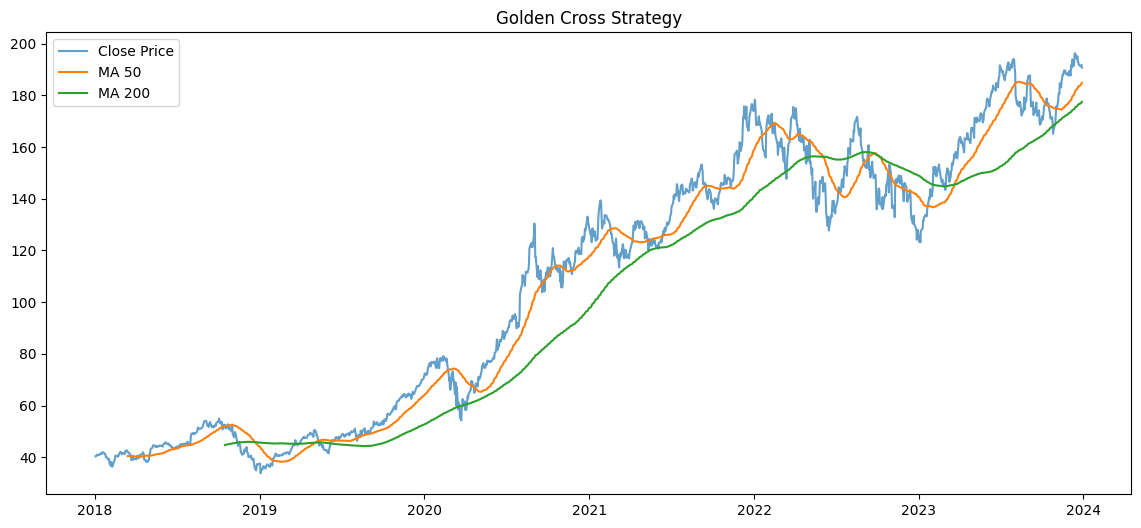

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(trader.data["Close"], label="Close Price", alpha=0.7)
plt.plot(trader.data["MA50"], label="MA 50")
plt.plot(trader.data["MA200"], label="MA 200")
plt.title("Golden Cross Strategy")
plt.legend()
plt.show()
